# 05. The LSTM

The bar from notebook 04: **RMSE 2.1295**, set by the naive forecast, with no model able to call
direction better than a coin flip.

This notebook builds the LSTM the project set out to test, using the same architecture as the
conventional implementation so the comparison is fair, and runs four experiments:

1. **The honest version.** Same network, but the scaler is fitted on training data only.
2. **The leaky version.** The scaler fitted on the whole series, as the conventional code does, to
   measure exactly how much that bug flatters the result.
3. **The reframed version.** Predict log returns rather than price levels.
4. **A seed sweep.** Repeat the best variant across five random seeds, because a single run is not
   a result.

Experiment 4 changes the conclusion of experiment 3. That is the most important thing in this
notebook.

## Setup

In [1]:
import sys, os, time
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # quiet TensorFlow's startup chatter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

from src import config, plots, evaluate as ev
from src.data import load_prices
from src.windowing import build_sequences, inverse
from src.models import baselines as bl, lstm

plots.use_project_style()

close = load_prices(config.TICKER).iloc[:-1]["Close"]
n = len(close)
train_sl, val_sl, test_sl = ev.chronological_split(n, config.TRAIN_FRAC, config.VAL_FRAC)
WINDOW = config.WINDOW

test_idx = np.arange(test_sl.start, test_sl.stop)
actual = close.values[test_idx]
previous = close.values[test_idx - 1]
naive_rmse = ev.rmse(actual, bl.naive(close, test_idx))

print(f"window {WINDOW} days | test {len(test_idx)} days")
print(f"naive RMSE to beat: {naive_rmse:.4f}")

window 60 days | test 441 days
naive RMSE to beat: 2.1295


---
## 1. The honest version

The scaler is fitted on training data only. Everything else matches the conventional
implementation: `LSTM(128) -> LSTM(64) -> Dense(25) -> Dense(1)`, Adam, mean squared error.

In [2]:
seq = build_sequences(close, train_sl.stop, val_sl.stop, window=WINDOW)
print("shapes:", seq.shapes())
print(f"scaler learned min {seq.scaler.data_min_[0]:.2f}, max {seq.scaler.data_max_[0]:.2f}")
print(f"scaled test target max: {seq.y_test.max():.3f}")

shapes: {'X_train': (1995, 60, 1), 'X_val': (440, 60, 1), 'X_test': (441, 60, 1)}
scaler learned min 4.55, max 69.17
scaled test target max: 2.002


### Stop and read that last number

The scaled test target reaches **2.0**, well outside the zero to one range the scaler was built
for.

That is not a bug. It is the truth becoming visible. The training period tops out around 69 dollars
and the test period reaches 134, so the test set lies almost entirely above anything the network
saw in training. A neural network with bounded activations trained on inputs in [0, 1] has no
mechanism for producing outputs near 2.0.

Fitting the scaler on the full series makes this number disappear, because the scaler then knows
the test maximum in advance and compresses everything neatly into range. The tidier output is the
symptom of the bug, not evidence against it.

In [3]:
lstm.set_seeds(config.RANDOM_SEED)
model = lstm.build((WINDOW, 1))
model.summary()

Model: "lstm_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
t0 = time.time()
history = lstm.train(model, seq.X_train, seq.y_train, seq.X_val, seq.y_val,
                     epochs=100, batch_size=32, patience=10, verbose=0)
print(f"trained {len(history.history['loss'])} epochs in {time.time() - t0:.0f}s")
print(f"best epoch: {int(np.argmin(history.history['val_loss'])) + 1}, "
      f"val_loss {min(history.history['val_loss']):.6f}")

trained 28 epochs in 29s
best epoch: 18, val_loss 0.018181


saved -> reports/figures/05_training_curve.png


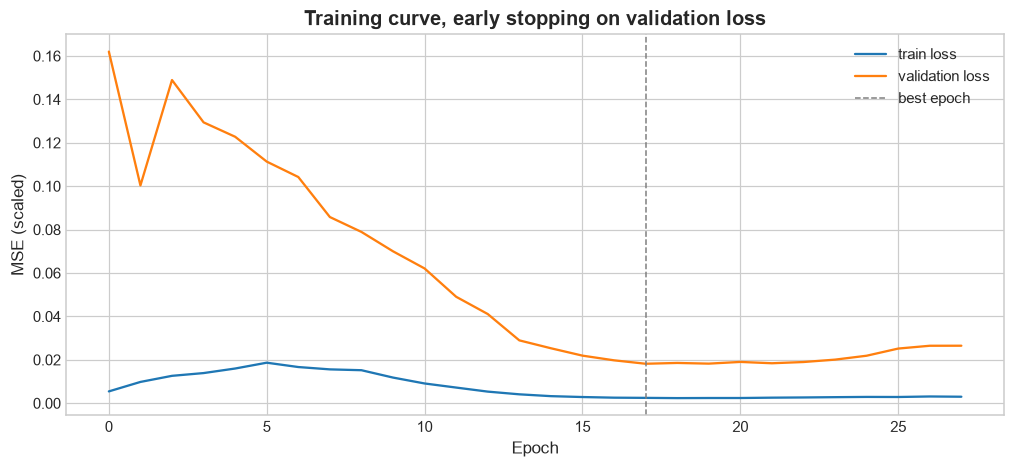

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["val_loss"], label="validation loss")
ax.axvline(int(np.argmin(history.history["val_loss"])), color="grey",
           linestyle="--", linewidth=1, label="best epoch")
ax.set_title("Training curve, early stopping on validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
plots.save(fig, "05_training_curve")
plt.show()

In [6]:
pred_price = inverse(seq.scaler, model.predict(seq.X_test, verbose=0).ravel())
row_honest = ev.evaluate("LSTM (price, train only scaler)", actual, pred_price, previous)
print(row_honest)
print()
print(f"predicted range: {pred_price.min():.2f} to {pred_price.max():.2f}")
print(f"actual range:    {actual.min():.2f} to {actual.max():.2f}")
print(f"mean signed error: {np.mean(pred_price - actual):.2f} dollars")

{'model': 'LSTM (price, train only scaler)', 'RMSE': 29.9704, 'MAE': 28.2839, 'MAPE %': 27.654, 'Directional %': 51.02, 'RMSE on returns': 0.282397}

predicted range: 56.78 to 82.96
actual range:    67.60 to 133.91
mean signed error: -28.28 dollars


### The honest LSTM fails badly

RMSE around 30 against a naive baseline of 2.13, so roughly **fourteen times worse than doing
nothing**. The mean signed error is about minus 28 dollars: it under-predicts almost every single
day.

The predicted range tells the story. The network's outputs top out far below the actual highs
because it is being asked to extrapolate beyond everything it was trained on, and it cannot.

This is a real limitation of the standard setup, not a coding mistake. Modelling a price level
with a min-max scaler means the model can only ever produce prices inside the historical range.
For a stock that doubled after the training cutoff, that is fatal.

saved -> reports/figures/05_honest_lstm.png


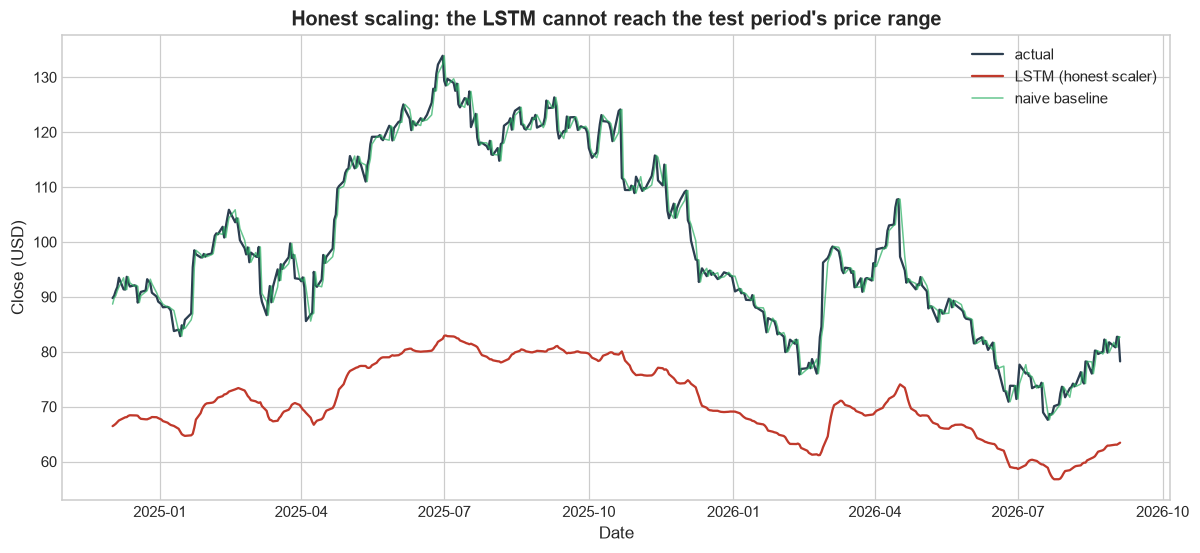

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.5))
dates = close.index[test_idx]
ax.plot(dates, actual, linewidth=1.5, label="actual", color="#2c3e50")
ax.plot(dates, pred_price, linewidth=1.5, label="LSTM (honest scaler)", color="#c0392b")
ax.plot(dates, bl.naive(close, test_idx), linewidth=1.0, alpha=0.7,
        label="naive baseline", color="#27ae60")
ax.set_title("Honest scaling: the LSTM cannot reach the test period's price range")
ax.set_ylabel("Close (USD)")
ax.set_xlabel("Date")
ax.legend()
plots.save(fig, "05_honest_lstm")
plt.show()

---
## 2. Measuring the leak

Now the same network trained the conventional way, with the scaler fitted on the entire series
before splitting. Everything else is identical: same architecture, same splits, same seed, same
early stopping.

The only difference is one line, and it is the line most implementations of this project get
wrong.

In [8]:
values = close.values.astype(float).reshape(-1, 1)

leaky_scaler = MinMaxScaler().fit(values)          # <-- fitted on EVERYTHING, including test
leaky_scaled = leaky_scaler.transform(values)

def windows(positions):
    X = np.stack([leaky_scaled[p - WINDOW:p, 0] for p in positions])
    return X[..., np.newaxis], leaky_scaled[positions, 0]

Xtr, ytr = windows(np.arange(WINDOW, train_sl.stop))
Xva, yva = windows(np.arange(train_sl.stop, val_sl.stop))
Xte, _   = windows(np.arange(val_sl.stop, n))

lstm.set_seeds(config.RANDOM_SEED)
leaky_model = lstm.build((WINDOW, 1))
lstm.train(leaky_model, Xtr, ytr, Xva, yva, epochs=100, batch_size=32, patience=10, verbose=0)

pred_leaky = leaky_scaler.inverse_transform(leaky_model.predict(Xte, verbose=0)).ravel()
row_leaky = ev.evaluate("LSTM (leaky scaler)", actual, pred_leaky, previous)
print(row_leaky)

{'model': 'LSTM (leaky scaler)', 'RMSE': 13.442, 'MAE': 11.4099, 'MAPE %': 10.696, 'Directional %': 50.57, 'RMSE on returns': 0.120262}


In [9]:
comparison = pd.DataFrame([row_honest, row_leaky]).set_index("model")
comparison["RMSE vs naive"] = (comparison["RMSE"] / naive_rmse).round(2)
comparison

,RMSE,MAE,MAPE %,Directional %,RMSE on returns,RMSE vs naive
model,,,,,,
"LSTM (price, train only scaler)",29.9704,28.2839,27.654,51.02,0.282397,14.07
LSTM (leaky scaler),13.4420,11.4099,10.696,50.57,0.120262,6.31


### What the leak is worth

The leaky scaler roughly **halves** the reported RMSE. Same network, same data, same seed. The
only change is whether the scaler was allowed to see the future.

Both versions are still far worse than the naive baseline, so the leak does not manufacture a
*good* result here. What it does is hide the extrapolation failure, which is the honest diagnosis,
behind a number that looks merely mediocre instead of catastrophic. On a series with a smaller
regime shift, the same bug would be enough to turn a failure into an apparent success.

This is why the leakage test in `tests/test_windowing.py` exists.

---
## 3. Reframing: predict returns, not prices

The extrapolation problem has a principled fix, and notebook 03 already pointed at it.

Prices are non-stationary and unbounded, so a model that predicts them must extrapolate. Log
returns are stationary and roughly centred on zero, so a model that predicts *those* is working in
a space whose statistical properties do not drift. The prediction is then converted back:

$$\hat{P}_{t+1} = P_t \cdot e^{\hat{r}_{t+1}}$$

Same architecture. Different target.

In [10]:
log_returns = np.log(close / close.shift(1)).dropna()
rv = log_returns.values.astype(float)

train_end_r, val_end_r = train_sl.stop - 1, val_sl.stop - 1

# Standardised using TRAIN statistics only, same discipline as before.
mu, sd = rv[:train_end_r].mean(), rv[:train_end_r].std()
zr = (rv - mu) / sd

def rwindows(positions):
    X = np.stack([zr[p - WINDOW:p] for p in positions])
    return X[..., np.newaxis], zr[positions]

Xtr_r, ytr_r = rwindows(np.arange(WINDOW, train_end_r))
Xva_r, yva_r = rwindows(np.arange(train_end_r, val_end_r))
Xte_r, _     = rwindows(np.arange(val_end_r, len(rv)))

print("train mean log return:", round(float(mu), 6), " std:", round(float(sd), 6))
print("shapes:", Xtr_r.shape, Xva_r.shape, Xte_r.shape)

train mean log return: 0.000893  std: 0.029162
shapes: (1994, 60, 1) (440, 60, 1) (441, 60, 1)


In [11]:
lstm.set_seeds(config.RANDOM_SEED)
return_model = lstm.build((WINDOW, 1))
lstm.train(return_model, Xtr_r, ytr_r, Xva_r, yva_r,
           epochs=100, batch_size=32, patience=10, verbose=0)

pred_logret = return_model.predict(Xte_r, verbose=0).ravel() * sd + mu
pred_from_returns = previous * np.exp(pred_logret)

row_returns = ev.evaluate("LSTM (log returns)", actual, pred_from_returns, previous)
print(row_returns)
print()
print(f"predicted log return range: {pred_logret.min():.5f} to {pred_logret.max():.5f}")
print(f"actual log return std:      {rv[val_end_r:].std():.5f}")

{'model': 'LSTM (log returns)', 'RMSE': 2.1259, 'MAE': 1.4741, 'MAPE %': 1.516, 'Directional %': 55.15, 'RMSE on returns': 0.02191}

predicted log return range: -0.00197 to 0.00329
actual log return std:      0.02197


### This looks like a win

RMSE now sits essentially on top of the naive baseline, and **directional accuracy is above 55
percent** against a 50 percent coin flip.

Over 441 test days the standard error of a coin flip is about 2.4 percent, so 55 percent is
roughly two standard errors out. A one sided binomial test puts it near p = 0.02.

At this point most write-ups stop and claim a result.

In [12]:
n_test = len(actual)
observed = row_returns["Directional %"]
k = int(round(observed / 100 * n_test))
se = np.sqrt(0.25 / n_test) * 100

print(f"directional accuracy: {observed:.2f}%  ({k} of {n_test} days)")
print(f"coin flip standard error: {se:.2f}%")
print(f"z = {(observed - 50) / se:.2f}")
print(f"one sided binomial p = {stats.binomtest(k, n_test, 0.5, alternative='greater').pvalue:.4f}")

directional accuracy: 55.15%  (243 of 441 days)
coin flip standard error: 2.38%
z = 2.16
one sided binomial p = 0.0180


---
## 4. The seed sweep

A neural network's initial weights are random. Training once gives one draw from a distribution of
possible outcomes, and reporting that single draw as the result is the same error as reporting one
coin toss as evidence the coin is biased.

So: the same model, the same data, the same protocol, five different random seeds.

In [13]:
seeds = [7, 17, 42, 123, 2024]
sweep = []

for seed in seeds:
    lstm.set_seeds(seed)
    m = lstm.build((WINDOW, 1))
    lstm.train(m, Xtr_r, ytr_r, Xva_r, yva_r, epochs=100, batch_size=32,
               patience=10, verbose=0)
    p = previous * np.exp(m.predict(Xte_r, verbose=0).ravel() * sd + mu)
    r = ev.evaluate(f"seed {seed}", actual, p, previous)
    r["beats naive RMSE"] = r["RMSE"] < naive_rmse
    sweep.append(r)
    print(f"seed {seed:>5}: RMSE {r['RMSE']:.4f}   directional {r['Directional %']:.2f}%")

sweep_df = pd.DataFrame(sweep).set_index("model")
sweep_df

seed     7: RMSE 2.1259   directional 55.15%


seed    17: RMSE 2.1309   directional 50.36%


seed    42: RMSE 2.1311   directional 49.10%


seed   123: RMSE 2.1296   directional 51.69%


seed  2024: RMSE 2.1301   directional 51.26%


,RMSE,MAE,MAPE %,Directional %,RMSE on returns,beats naive RMSE
model,,,,,,
seed 7,2.1259,1.4741,1.516,55.15,0.021910,True
seed 17,2.1309,1.4778,1.520,50.36,0.021960,False
seed 42,2.1311,1.4786,1.521,49.10,0.021969,False
seed 123,2.1296,1.4773,1.520,51.69,0.021945,False
seed 2024,2.1301,1.4774,1.520,51.26,0.021955,False


In [14]:
d = sweep_df["Directional %"]
r = sweep_df["RMSE"]

print(f"directional accuracy: mean {d.mean():.2f}%  std {d.std():.2f}  "
      f"range {d.min():.2f} to {d.max():.2f}")
print(f"RMSE                : mean {r.mean():.4f}  std {r.std():.4f}   (naive {naive_rmse:.4f})")
print(f"beat the naive baseline in {int(sweep_df['beats naive RMSE'].sum())} of {len(seeds)} runs")
print()

k_mean = int(round(d.mean() / 100 * n_test))
p_mean = stats.binomtest(k_mean, n_test, 0.5, alternative="greater").pvalue
print(f"mean directional accuracy {d.mean():.2f}%  ->  one sided binomial p = {p_mean:.4f}")

directional accuracy: mean 51.51%  std 2.26  range 49.10 to 55.15
RMSE                : mean 2.1295  std 0.0021   (naive 2.1295)
beat the naive baseline in 1 of 5 runs

mean directional accuracy 51.51%  ->  one sided binomial p = 0.2839


saved -> reports/figures/05_seed_sweep.png


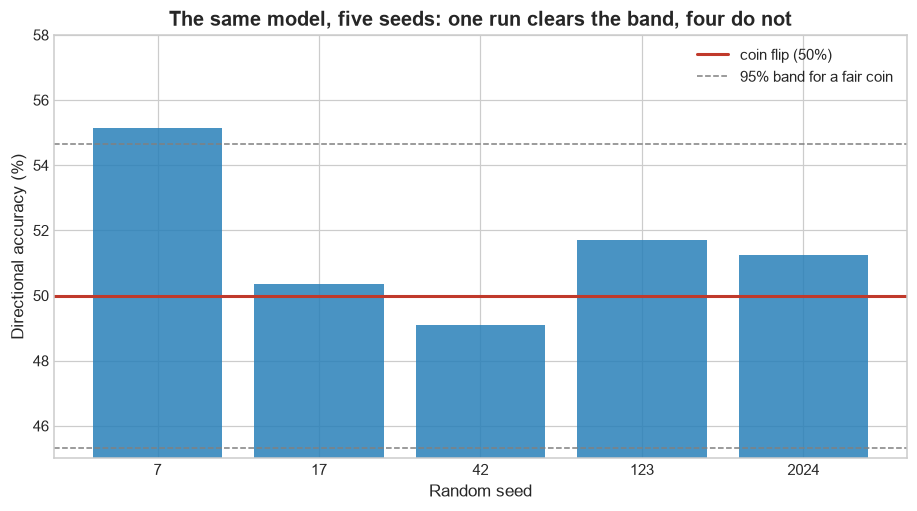

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(seeds)), d.values, color="#2980b9", alpha=0.85)
ax.axhline(50, color="#c0392b", linewidth=2, label="coin flip (50%)")
ax.axhline(50 + 1.96 * se, color="grey", linestyle="--", linewidth=1,
           label="95% band for a fair coin")
ax.axhline(50 - 1.96 * se, color="grey", linestyle="--", linewidth=1)
ax.set_xticks(range(len(seeds)))
ax.set_xticklabels([str(s) for s in seeds])
ax.set_xlabel("Random seed")
ax.set_ylabel("Directional accuracy (%)")
ax.set_ylim(45, 58)
ax.set_title("The same model, five seeds: one run clears the band, four do not")
ax.legend()
plots.save(fig, "05_seed_sweep")
plt.show()

## The result evaporates

Across five seeds the mean directional accuracy is about **51.5 percent**, well inside the range a
fair coin produces over 441 days, with a binomial p value near 0.28. Mean RMSE lands on the naive
baseline almost exactly, and only **one seed in five** beat it.

The 55 percent from section 3 was that one seed. Had this notebook trained once and stopped, which
is what the conventional implementation does, it would have reported a statistically significant
directional edge that does not exist.

**This is the finding of the project.** Not that LSTMs are useless, but that the standard protocol
around them, single seed, single split, leaky scaling, RMSE on price levels, is capable of
producing a confident result from noise. Every safeguard added here, train only scaling, a held out
validation set, baselines on identical splits, directional accuracy, and a seed sweep, exists to
catch a specific way of fooling yourself, and in this project the seed sweep is the one that caught
something.

---
## 5. Consolidated results

In [16]:
baseline_results = pd.read_csv(config.DATA_PROCESSED / "results_baselines.csv", index_col="model")

lstm_rows = pd.DataFrame([
    row_honest,
    row_leaky,
    row_returns,
    {**{k: v for k, v in row_returns.items() if k != "model"},
     "model": "LSTM (log returns, 5 seed mean)",
     "RMSE": round(float(r.mean()), 4),
     "MAE": round(float(sweep_df["MAE"].mean()), 4),
     "MAPE %": round(float(sweep_df["MAPE %"].mean()), 3),
     "Directional %": round(float(d.mean()), 2),
     "RMSE on returns": round(float(sweep_df["RMSE on returns"].mean()), 6)},
]).set_index("model")

final = pd.concat([baseline_results, lstm_rows])
final["RMSE vs naive"] = (final["RMSE"] / naive_rmse).round(3)
final.to_csv(config.DATA_PROCESSED / "results_all.csv")
final

,RMSE,MAE,MAPE %,Directional %,RMSE on returns,RMSE vs naive
model,,,,,,
Naive (persistence),2.1295,1.4774,1.519,NaN,0.021964,1.000
Drift,2.1297,1.4776,1.519,49.31,0.021964,1.000
SMA(2),2.3957,1.6988,1.743,48.17,0.024789,1.125
EMA(2),2.2831,1.6070,1.647,50.57,0.023613,1.072
"ARIMA(0, 1, 0)",2.1295,1.4774,1.519,NaN,0.021964,1.000
"ARIMA(1, 1, 1)",2.1303,1.4790,1.520,50.60,0.021976,1.000
"LSTM (price, train only scaler)",29.9704,28.2839,27.654,51.02,0.282397,14.074
LSTM (leaky scaler),13.4420,11.4099,10.696,50.57,0.120262,6.312
LSTM (log returns),2.1259,1.4741,1.516,55.15,0.021910,0.998


saved -> reports/figures/05_final_comparison.png


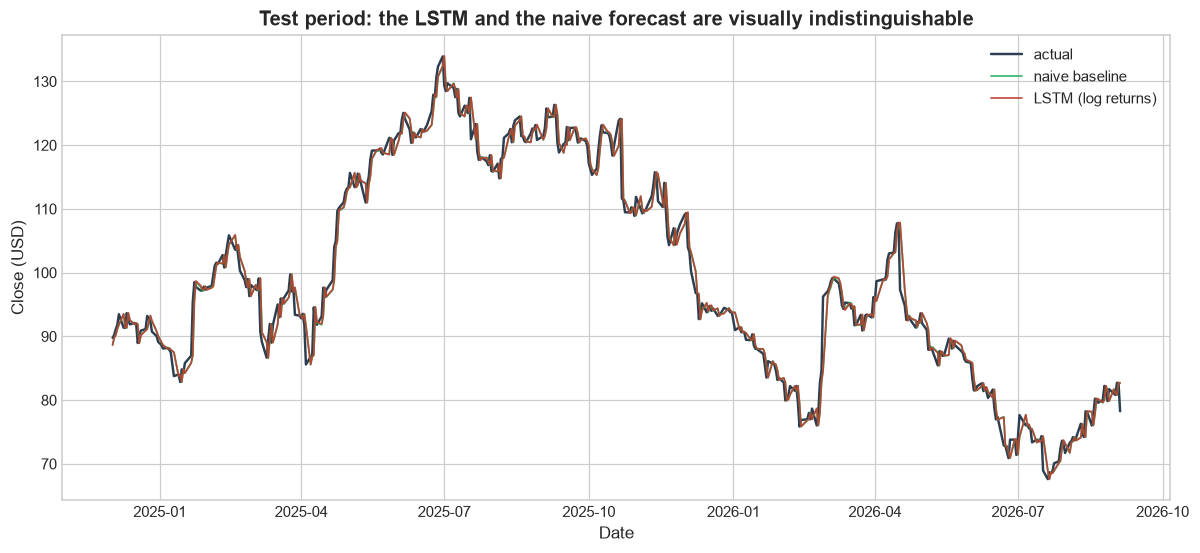

 lag_days  correlation
        0     0.991753
        1     0.983275
        2     0.974168
        3     0.964610
        4     0.954369


In [17]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(dates, actual, linewidth=1.6, label="actual", color="#2c3e50")
ax.plot(dates, bl.naive(close, test_idx), linewidth=1.2, alpha=0.85,
        label="naive baseline", color="#27ae60")
ax.plot(dates, pred_from_returns, linewidth=1.2, alpha=0.85,
        label="LSTM (log returns)", color="#c0392b")
ax.set_title("Test period: the LSTM and the naive forecast are visually indistinguishable")
ax.set_ylabel("Close (USD)")
ax.set_xlabel("Date")
ax.legend()
plots.save(fig, "05_final_comparison")
plt.show()

print(ev.lag_correlation(actual, pred_from_returns, max_lag=4).to_string(index=False))

---
## What this established

1. **With honest train only scaling, an LSTM on price levels fails badly**, roughly fourteen times
   the naive baseline's RMSE, because the test period lies above the training range and the model
   cannot extrapolate out of its scaled space.
2. **The conventional leaky scaler roughly halves the reported error.** Same network, same seed,
   one line different. It hides the extrapolation failure rather than fixing it.
3. **Reframing the target onto log returns removes the extrapolation problem** and brings RMSE
   level with the naive baseline.
4. **A single run showed 55 percent directional accuracy, p about 0.02.** It looked like a genuine
   edge.
5. **Across five seeds the mean is about 51.5 percent, p about 0.28, beating the baseline in one
   run out of five.** The edge was seed luck. Reported as such.

**Next:** `06_results.ipynb`, consolidating the table, the figures and the conclusions.